# AdaBoost Regressor - California Housing Dataset
### Target: Predict median_house_value

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Step 1 - Load Dataset

In [2]:
df = pd.read_csv('california_housing.csv')
print("Shape:", df.shape)
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  str    
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), str(1)
memory usage: 1.7 MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
# Missing values check
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

In [13]:
df.isnull().sum() / len(df) * 100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
ocean_proximity       0.000000
median_house_value    0.000000
dtype: float64

In [15]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())


## Step 2 - EDA

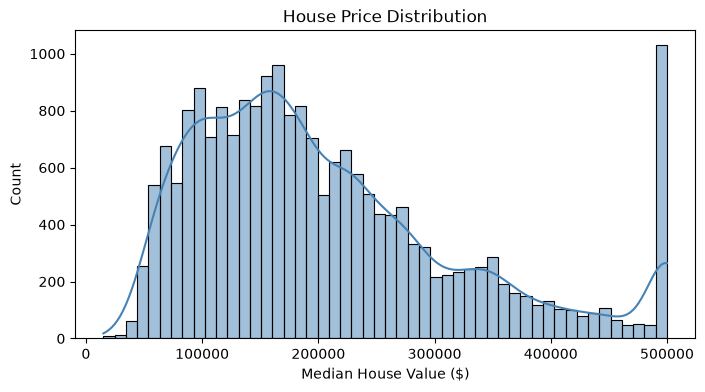

In [16]:
# Target distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='steelblue')
plt.title('House Price Distribution')
plt.xlabel('Median House Value ($)')
plt.show()

In [17]:
# ocean_proximity categories
print(df['ocean_proximity'].value_counts())

ocean_proximity
0    9136
1    6551
4    2658
3    2290
2       5
Name: count, dtype: int64


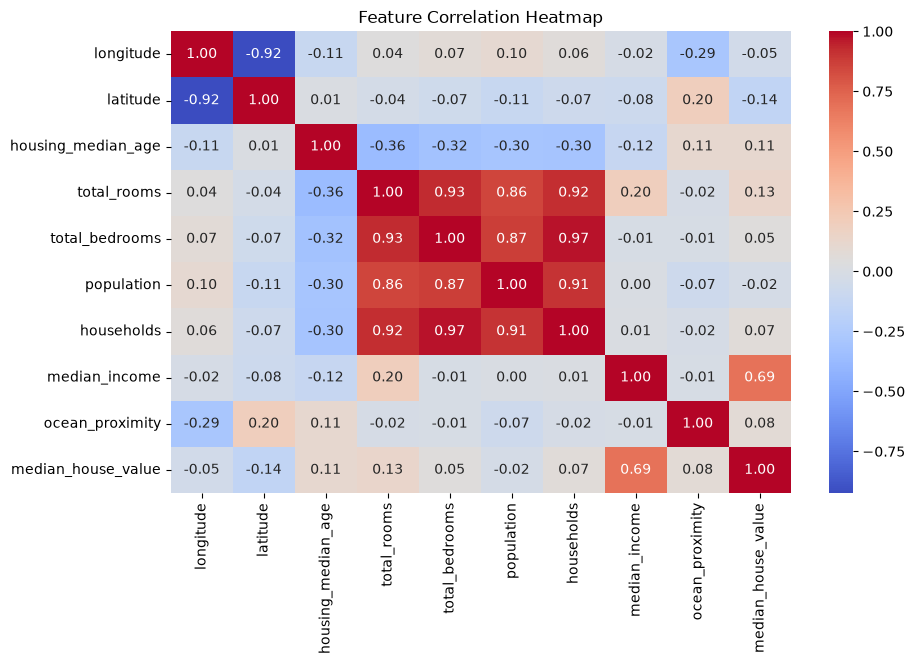

In [18]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Step 3 - Preprocessing

In [20]:


# Encode ocean_proximity
le = LabelEncoder()
df['ocean_proximity'] = le.fit_transform(df['ocean_proximity'])

print("Missing values after fix:", df.isnull().sum().sum())
df.head()

Missing values after fix: 0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,3,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,3,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,3,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,3,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,3,342200


## Step 4 - Train Test Split

In [21]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (16512, 9)
Test size:  (4128, 9)


## Step 5 - Train AdaBoost Regressor

In [22]:
ada_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=100,
    learning_rate=0.1,
    loss='linear',
    random_state=42
)

ada_reg.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


## Step 6 - Evaluation

In [23]:
y_pred = ada_reg.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2 Score : {r2:.4f}")
print(f"MAE      : ${mae:,.0f}")
print(f"RMSE     : ${rmse:,.0f}")

R2 Score : 0.5827
MAE      : $60,140
RMSE     : $73,952


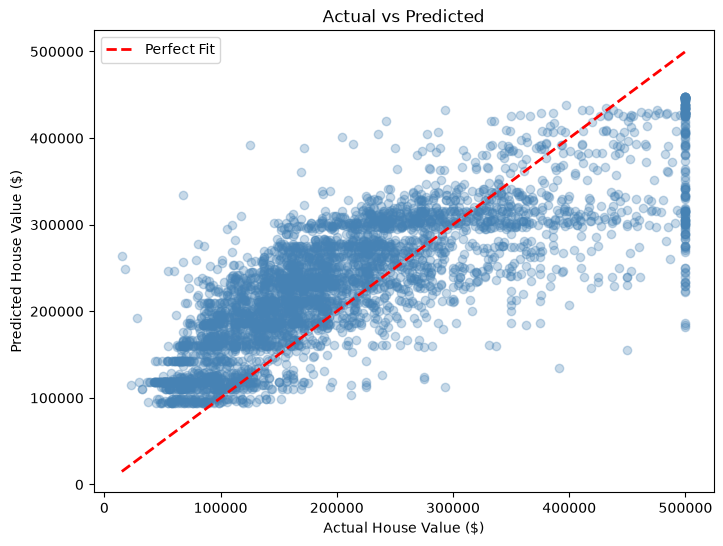

In [24]:
# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual House Value ($)')
plt.ylabel('Predicted House Value ($)')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

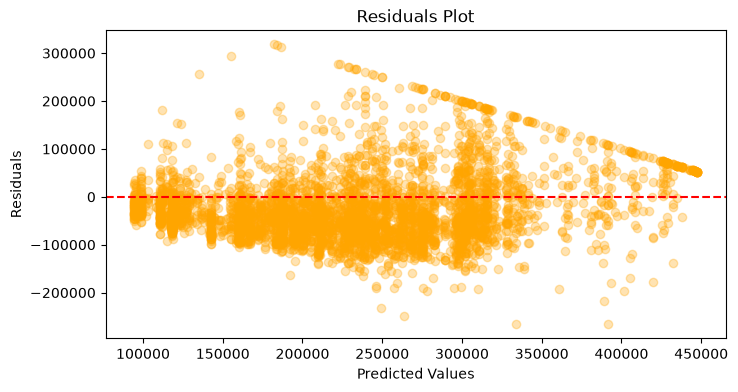

In [25]:
# Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.3, color='orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.show()

## Step 7 - Feature Importance

C:\Users\poona\AppData\Local\Temp\ipykernel_19436\2391719300.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


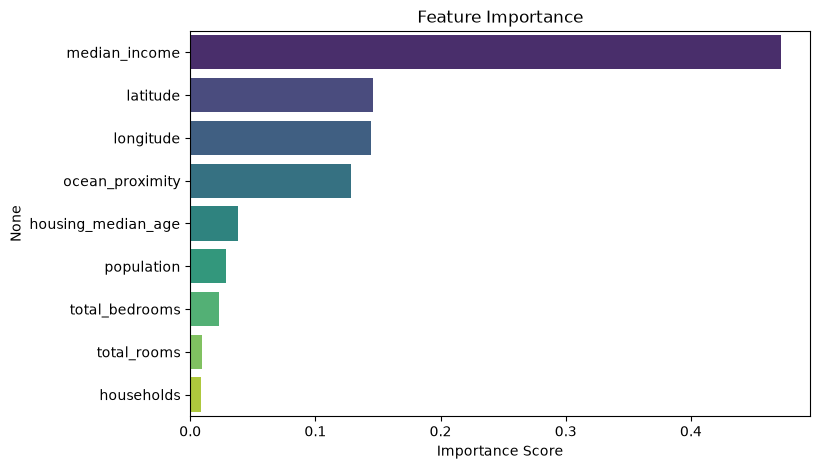

median_income         0.471681
latitude              0.146326
longitude             0.144773
ocean_proximity       0.128781
housing_median_age    0.038369
population            0.028804
total_bedrooms        0.022685
total_rooms           0.009677
households            0.008905
dtype: float64


In [26]:
feat_imp = pd.Series(ada_reg.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()

print(feat_imp)

## Step 8 - Compare Loss Functions

In [27]:
print(f"{'Loss':<15} {'R2':>8} {'MAE':>12} {'RMSE':>12}")
print("-" * 50)

for loss in ['linear', 'square', 'exponential']:
    model = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4),
        n_estimators=100,
        learning_rate=0.1,
        loss=loss,
        random_state=42
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2   = r2_score(y_test, preds)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{loss:<15} {r2:>8.4f} {mae:>12,.0f} {rmse:>12,.0f}")

Loss                  R2          MAE         RMSE
--------------------------------------------------
linear            0.5827       60,140       73,952
square            0.5125       67,025       79,925
exponential       0.5955       58,396       72,801


## Step 9 - Effect of n_estimators

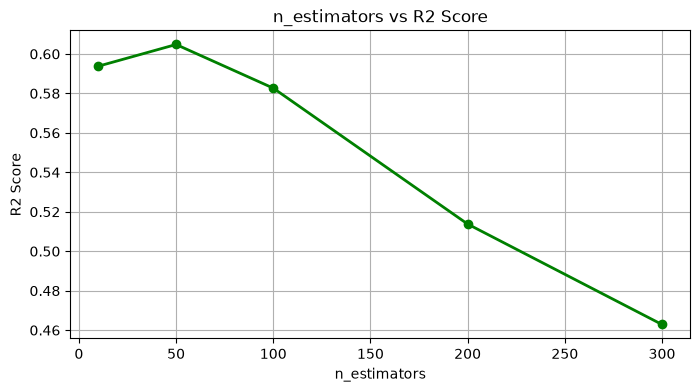

In [28]:
estimator_range = [10, 50, 100, 200, 300]
r2_scores = []

for n in estimator_range:
    model = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4),
        n_estimators=n,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_train, y_train)
    r2_scores.append(r2_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(estimator_range, r2_scores, marker='o', color='green', linewidth=2)
plt.xlabel('n_estimators')
plt.ylabel('R2 Score')
plt.title('n_estimators vs R2 Score')
plt.grid(True)
plt.show()